# Modelo 2D axisimétrico del conducto — Calbuco 2015

## Formulación: diferencias finitas en $r$ **y** en $z$

$$\frac{1}{r}\frac{\partial}{\partial r}\left[r\,\mu(1-\phi)\frac{\partial u_m}{\partial r}\right] = (1-\phi)\frac{dP}{dz} + \rho_m(1-\phi)\,g - F_{mg}$$

Condición de borde: $u_m(r=R)=0$ (pared sin deslizamiento), $\partial u_m/\partial r = 0$ en $r=0$ (simetría).

## Estrategia numérica (`RIconduit2D_FD.py`)

| Dirección | Método |
|-----------|--------|
| Radial $r$ | FD + algoritmo de Thomas + Picard para $\mu$ no lineal |
| Vertical $z$ | RK4 explícito (marcha desde $z=H$ hasta $z=0$) |
| Fricción parietal | $F_{mw}$ del gradiente real $\partial u_m/\partial r\big|_{r=R}$ (no Hagen-Poiseuille) |
| Tiro | Bisección + secante sobre $v_{\rm inicial}$ |

**Sin solver DAE (sin IDA)** — toda la integración es explícita y controlable.

Ejecutar las celdas en orden. El método de tiro puede tardar ~2–5 min.

In [1]:
%load_ext autoreload
%autoreload 2

from RIconduit2D_FD import RIconduit2D_FD_f, radial_grid
from calbuco2015d import radius1, overP1, h2o1, T1, xi1, geometry, pfinal
import numpy as np

In [2]:
radius  = radius1   # 16 m
Pressure = overP1   # 5e6 Pa sobrepresión

In [3]:
# ── Correr el modelo 2D FD ──────────────────────────────────────────────
# N_r: nodos radiales | N_z: pasos en z (más pasos = más lento pero más preciso)
out = RIconduit2D_FD_f(radius, Pressure, h2o1, T1, xi1, N_r=20, N_z=3000)

[zsolex, soluex, countex, vex,
 rho_m, rbubex, viscex, rho_ti,
 fragcritex, phicritex,
 limphi1ex, limphi2ex,
 coex, xiex, xfinalex, cgex,
 sol_fullex] = out

print(f"Iteraciones: {countex} | v_inicial = {vex:.4f} m/s")
print(f"z final = {zsolex[-1]:.1f} m | P final = {soluex[-1,0]/1e6:.3f} MPa")
print(f"u_g salida = {soluex[-1,5]:.2f} m/s | phi salida = {soluex[-1,1]:.3f}")


Count = 1  vinicial = 10.00000
  [march] pasos=304  rechazos=0  dz_final=11.75 m
  v=10.0000  z=0.0  P=1.344e+07  ug=29.692  phi=0.670
  vmin=10.0000  vmax=50.0000

Count = 2  vinicial = 30.00000
  [march] pasos=304  rechazos=0  dz_final=12.91 m
  v=30.0000  z=0.0  P=3.479e+06  ug=102.291  phi=0.708
  vmin=30.0000  vmax=50.0000

Count = 3  vinicial = 40.00000
  [march] pasos=296  rechazos=9  dz_final=9.93 m
  v=40.0000  z=-176.8  P=5.066e+04  ug=137.204  phi=0.708
  vmin=30.0000  vmax=40.0000

Count = 4  vinicial = 35.00000
  [march] pasos=307  rechazos=3  dz_final=13.16 m
  v=35.0000  z=0.0  P=4.292e+05  ug=119.970  phi=0.708
  vmin=35.0000  vmax=40.0000

Count = 5  vinicial = 37.50000
  [march] pasos=302  rechazos=8  dz_final=9.37 m
  v=37.5000  z=-70.5  P=5.066e+04  ug=128.630  phi=0.708
  vmin=35.0000  vmax=37.5000

Count = 6  vinicial = 36.25000
  [march] pasos=307  rechazos=7  dz_final=11.21 m
  v=36.2500  z=-17.0  P=5.066e+04  ug=124.341  phi=0.708
  vmin=35.0000  vmax=36.2500


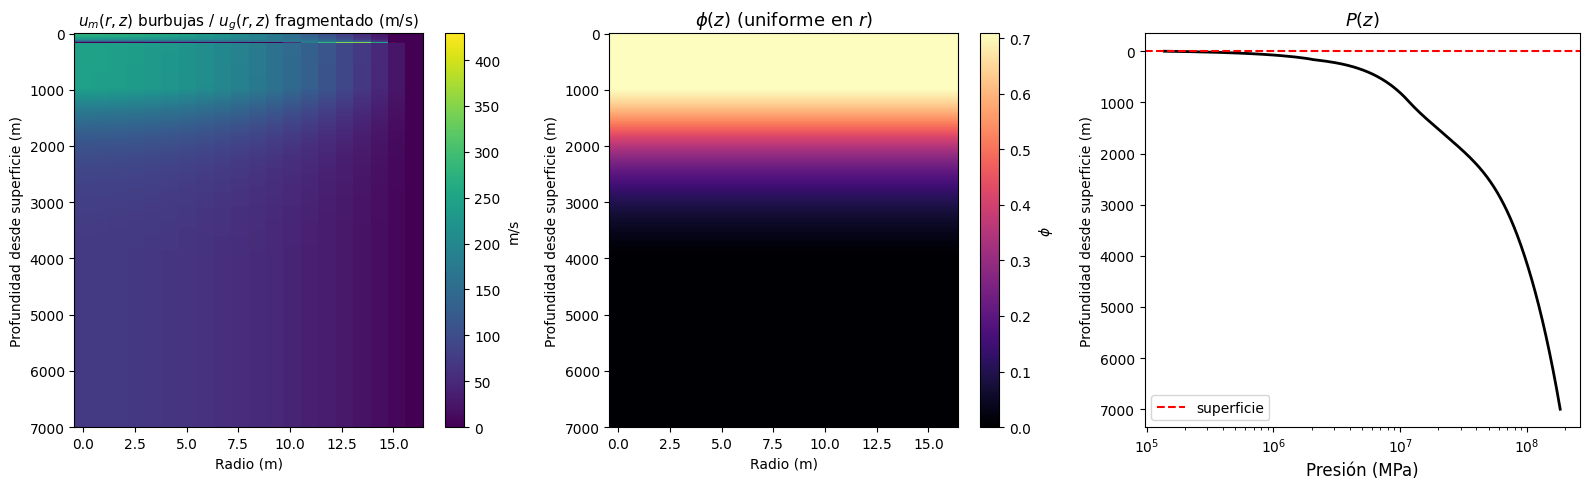

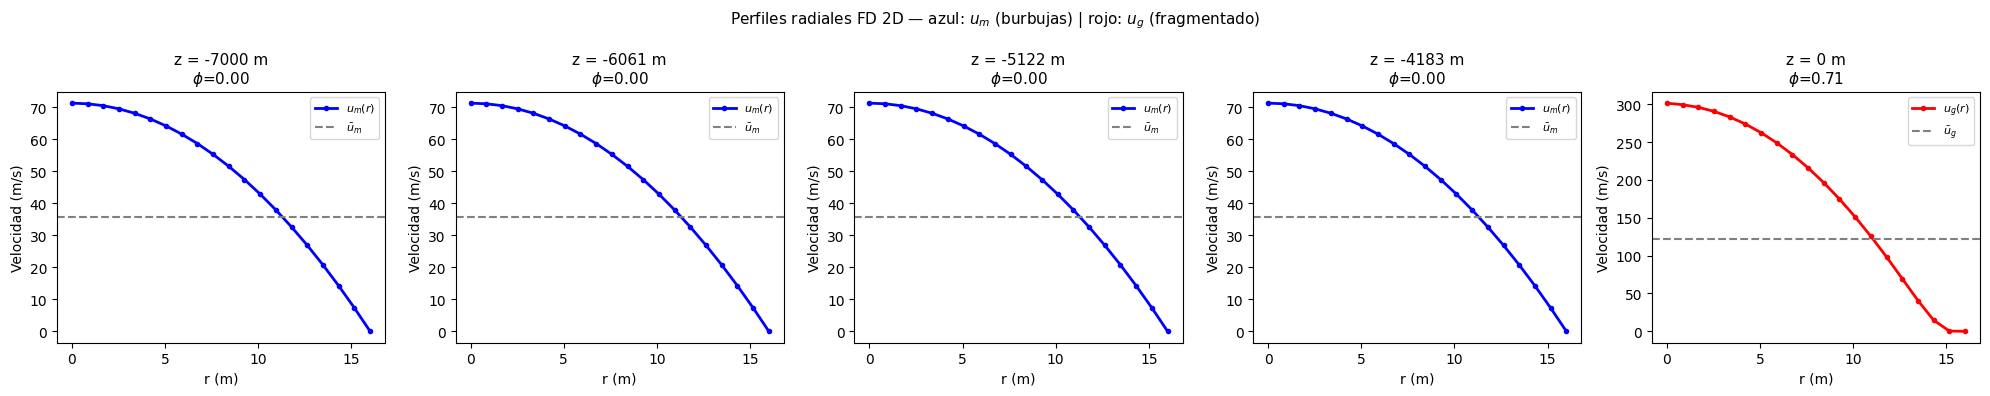

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from RIconduit2D_FD import radial_grid

r_plot, wr_plot, N_rad = radial_grid()

# sol_fullex: [P, phi, Nd, x, um_avg, ug, u(r)...]
# En régimen de burbujas: u(r) = u_m(r) (fundido)
# En régimen fragmentado: u(r) = u_g(r) (gas)
U_2D  = sol_fullex[:, 6:6 + N_rad]
Phi_z = soluex[:, 1]
Phi_2D = np.tile(Phi_z[:, None], (1, N_rad))

# Determinar régimen en cada z para el label correcto
phicrit_val = soluex[:, 1].max()   # aproximación: phicrit del run
frag_mask = Phi_z >= (phicrit_val * 0.99)   # True donde hay fragmentación

depth = -zsolex                           # profundidad positiva (0 = superficie)
R_mesh, Z_mesh = np.meshgrid(r_plot, depth)

# ── mapa 2D ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

c1 = axes[0].pcolormesh(R_mesh, Z_mesh, U_2D, shading='auto', cmap='viridis')
axes[0].set_title('$u_m(r,z)$ burbujas / $u_g(r,z)$ fragmentado (m/s)', fontsize=11)
axes[0].set_xlabel('Radio (m)'); axes[0].set_ylabel('Profundidad desde superficie (m)')
axes[0].invert_yaxis()
fig.colorbar(c1, ax=axes[0], label='m/s')

c2 = axes[1].pcolormesh(R_mesh, Z_mesh, Phi_2D, shading='auto', cmap='magma')
axes[1].set_title('$\\phi(z)$ (uniforme en $r$)', fontsize=13)
axes[1].set_xlabel('Radio (m)'); axes[1].set_ylabel('Profundidad desde superficie (m)')
axes[1].invert_yaxis()
fig.colorbar(c2, ax=axes[1], label='$\\phi$')

axes[2].plot(soluex[:, 0], depth, 'k-', lw=2)
axes[2].set_xscale('log'); #axes[2].set_xlim(1e5, 1e7)
axes[2].set_xlabel('Presión (MPa)', fontsize=12)
axes[2].set_ylabel('Profundidad desde superficie (m)')
axes[2].set_title('$P(z)$', fontsize=13)
axes[2].invert_yaxis()
axes[2].axhline(0, color='r', ls='--', label='superficie')
axes[2].legend()
plt.tight_layout(); plt.show()

# ── perfiles radiales en 5 profundidades ─────────────────────────────────────
nz = len(zsolex)
idxs = [0, nz // 4, nz // 2, 3 * nz // 4, nz - 1]
idxs = sorted(set(np.clip(idxs, 0, nz - 1)))

fig, axes2 = plt.subplots(1, len(idxs), figsize=(4*len(idxs), 4), sharey=False)
if len(idxs) == 1:
    axes2 = [axes2]
for ax, j in zip(axes2, idxs):
    u_r   = sol_fullex[j, 6:6+N_rad]
    phi_j = soluex[j, 1]
    is_frag = frag_mask[j]
    color  = 'r' if is_frag else 'b'
    label_u = '$u_g(r)$' if is_frag else '$u_m(r)$'
    label_avg = '$\\bar{u}_g$' if is_frag else '$\\bar{u}_m$'
    u_avg  = soluex[j, 5] if is_frag else soluex[j, 4]
    ax.plot(r_plot, u_r, color=color, marker='o', ms=3, lw=2, label=label_u)
    ax.axhline(u_avg, color='gray', ls='--', label=label_avg)
    ax.set_title(f'z = {zsolex[j]:.0f} m\n$\\phi$={phi_j:.2f}', fontsize=11)
    ax.set_xlabel('r (m)')
    ax.set_ylabel('Velocidad (m/s)')
    ax.legend(fontsize=8)
plt.suptitle('Perfiles radiales FD 2D — azul: $u_m$ (burbujas) | rojo: $u_g$ (fragmentado)',
             fontsize=11)
plt.tight_layout(); plt.show()


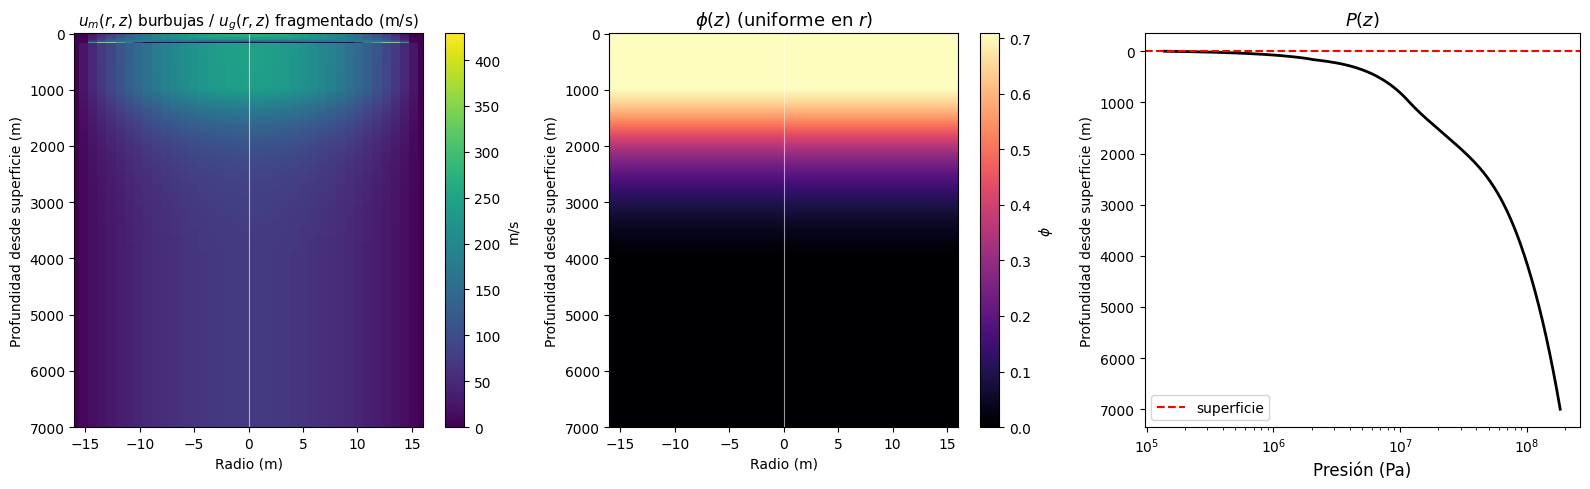

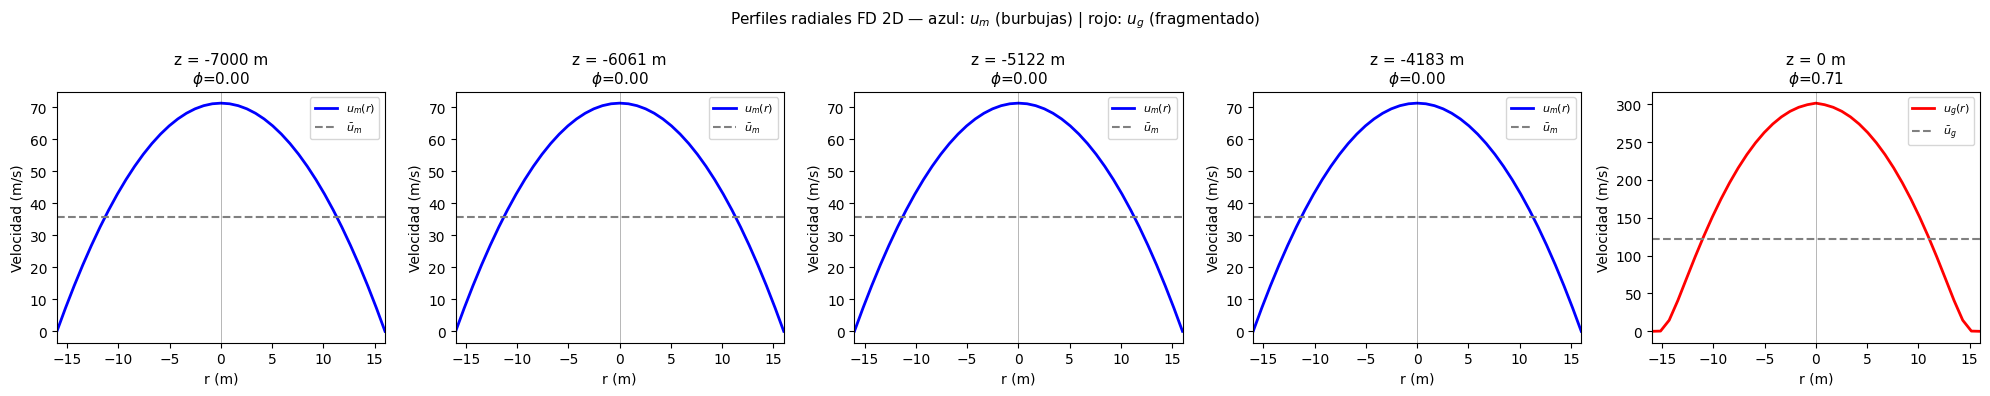

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from RIconduit2D_FD import radial_grid
r_plot, wr_plot, N_rad = radial_grid()
# ── Datos ────────────────────────────────────────────────────────────────────
U_2D   = sol_fullex[:, 6:6 + N_rad]
Phi_z  = soluex[:, 1]
Phi_2D = np.tile(Phi_z[:, None], (1, N_rad))
phicrit_val = soluex[:, 1].max()
frag_mask = Phi_z >= (phicrit_val * 0.99)
depth = -zsolex
# ── Simetría en r: [-wr, 0) ∪ [0, wr] ───────────────────────────────────────
r_symm = np.concatenate([-r_plot[::-1], r_plot[1:]])
U_symm = np.concatenate([U_2D[:, ::-1], U_2D[:, 1:]], axis=1)
Phi_symm = np.concatenate([Phi_2D[:, ::-1], Phi_2D[:, 1:]], axis=1)
R_mesh, Z_mesh = np.meshgrid(r_symm, depth)
# ── mapa 2D ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c1 = axes[0].pcolormesh(R_mesh, Z_mesh, U_symm, shading='auto', cmap='viridis')
axes[0].set_title('$u_m(r,z)$ burbujas / $u_g(r,z)$ fragmentado (m/s)', fontsize=11)
axes[0].set_xlabel('Radio (m)')
axes[0].set_ylabel('Profundidad desde superficie (m)')
axes[0].set_xlim(-wr_plot, wr_plot)
axes[0].axvline(0, color='w', lw=0.8, alpha=0.6)   # eje del conducto
axes[0].invert_yaxis()
fig.colorbar(c1, ax=axes[0], label='m/s')
c2 = axes[1].pcolormesh(R_mesh, Z_mesh, Phi_symm, shading='auto', cmap='magma')
axes[1].set_title('$\\phi(z)$ (uniforme en $r$)', fontsize=13)
axes[1].set_xlabel('Radio (m)')
axes[1].set_ylabel('Profundidad desde superficie (m)')
axes[1].set_xlim(-wr_plot, wr_plot)
axes[1].axvline(0, color='w', lw=0.8, alpha=0.6)
axes[1].invert_yaxis()
fig.colorbar(c2, ax=axes[1], label='$\\phi$')
axes[2].plot(soluex[:, 0], depth, 'k-', lw=2)
axes[2].set_xscale('log')
axes[2].set_xlabel('Presión (Pa)', fontsize=12)
axes[2].set_ylabel('Profundidad desde superficie (m)')
axes[2].set_title('$P(z)$', fontsize=13)
axes[2].invert_yaxis()
axes[2].axhline(0, color='r', ls='--', label='superficie')
axes[2].legend()
plt.tight_layout()
plt.show()
# ── perfiles radiales en 5 profundidades (simétricos) ────────────────────────
nz = len(zsolex)
idxs = sorted(set(np.clip([0, nz // 4, nz // 2, 3 * nz // 4, nz - 1], 0, nz - 1)))
fig, axes2 = plt.subplots(1, len(idxs), figsize=(4 * len(idxs), 4), sharey=False)
if len(idxs) == 1:
    axes2 = [axes2]
for ax, j in zip(axes2, idxs):
    u_r = sol_fullex[j, 6:6 + N_rad]
    r_full = np.concatenate([-r_plot[::-1], r_plot[1:]])
    u_full = np.concatenate([u_r[::-1], u_r[1:]])
    phi_j = soluex[j, 1]
    is_frag = frag_mask[j]
    color = 'r' if is_frag else 'b'
    label_u = '$u_g(r)$' if is_frag else '$u_m(r)$'
    label_avg = '$\\bar{u}_g$' if is_frag else '$\\bar{u}_m$'
    u_avg = soluex[j, 5] if is_frag else soluex[j, 4]
    ax.plot(r_full, u_full, color=color, lw=2, label=label_u)
    ax.axhline(u_avg, color='gray', ls='--', label=label_avg)
    ax.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax.set_xlim(-wr_plot, wr_plot)
    ax.set_title(f'z = {zsolex[j]:.0f} m\n$\\phi$={phi_j:.2f}', fontsize=11)
    ax.set_xlabel('r (m)')
    ax.set_ylabel('Velocidad (m/s)')
    ax.legend(fontsize=8)
plt.suptitle('Perfiles radiales FD 2D — azul: $u_m$ (burbujas) | rojo: $u_g$ (fragmentado)',
             fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# ── Resumen numérico ─────────────────────────────────────────────────────────
r_plot, wr_plot, N_rad = radial_grid()
um_centro = float(sol_fullex[-1, 6])     # r ≈ 0
um_medio  = float(sol_fullex[-1, 6 + N_rad//2])
um_pared  = float(sol_fullex[-1, -1])    # = 0 por BC

if geometry == "dyke":
    from calbuco2015d import dl
    Q_vol = vex * wr_plot * dl
else:
    Q_vol = vex * np.pi * wr_plot**2

print("=" * 50)
print(f"  Iteraciones de tiro : {countex}")
print(f"  v_inicial final     : {vex:.4f} m/s")
print(f"  Profundidad final   : {zsolex[-1]:.1f} m  (meta >= -5 m)")
print(f"  P salida            : {soluex[-1,0]/1e6:.3f} MPa  (P_atm = {pfinal/1e6:.4f} MPa)")
print(f"  u_g salida          : {soluex[-1,5]:.2f} m/s")
print(f"  phi salida          : {soluex[-1,1]:.3f}")
print(f"  u_m(r=0)            : {um_centro:.3f} m/s")
print(f"  u_m(r=R/2)          : {um_medio:.3f} m/s")
print(f"  u_m(r=R)            : {um_pared:.4f} m/s (BC exacta)")
print(f"  Caudal vol.         : {Q_vol:.2f} m³/s")
print(f"  Caudal mas.         : {Q_vol*rho_ti:.2f} kg/s")
print("=" * 50)


  Iteraciones de tiro : 7
  v_inicial final     : 35.6250 m/s
  Profundidad final   : 0.0 m  (meta >= -5 m)
  P salida            : 0.138 MPa  (P_atm = 0.1013 MPa)
  u_g salida          : 122.17 m/s
  phi salida          : 0.708
  u_m(r=0)            : 301.523 m/s
  u_m(r=R/2)          : 196.387 m/s
  u_m(r=R)            : 0.0000 m/s (BC exacta)
  Caudal vol.         : 28651.33 m³/s
  Caudal mas.         : 70573711.81 kg/s


In [ ]:
wr=radius
if countex>=49:
    solex=False
else:
    solex=True

if geometry=="dyke":
    Qex=vex*wr*dl
else:
    Qex=vex*np.pi*wr*wr

#print(Qex, T1, xi1, h2o1)

import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que soluex y zsolex están definidos como arrays de numpy
if solex:  # Verifica si 'solex' está definido y es verdadero

    fig, axs = plt.subplots(1, 6, figsize=(18, 6))  # Crear una figura con 6 subgráficos en una fila

    # Subplot 1
    axs[0].semilogx(soluex[:, 0], zsolex, linewidth=2)
    axs[0].set_xlabel('Pressure (Pa)', fontweight='bold', fontsize=14)
    axs[0].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 2
    axs[1].plot(soluex[:, 1], zsolex, linewidth=2)
    axs[1].set_xlabel('gas volume fraction', fontweight='bold', fontsize=14)
    axs[1].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 3
    axs[2].semilogx(soluex[:, 4], zsolex, label='Velocity liq', linewidth=2)
    axs[2].semilogx(soluex[:, 5], zsolex, '--', label='Velocity gas', linewidth=2)
    axs[2].set_xlabel('velocity (m/s)', fontweight='bold', fontsize=14)
    axs[2].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    axs[2].legend()

    # Añadir anotación
    str2 = f'mass flow rate = {Qex*rho_ti:.3g} kg/s'
    fig.text(0.65, 0.87, str2, bbox=dict(facecolor='white', edgecolor='black'))

    # Subplot 4
    axs[3].plot(soluex[:, 2], zsolex, linewidth=2)
    axs[3].set_xlabel('Nd', fontweight='bold', fontsize=14)
    axs[3].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 5
    axs[4].plot(soluex[:, 3], zsolex, linewidth=2)
    axs[4].set_xlabel('crystal content', fontweight='bold', fontsize=14)
    axs[4].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 6
    axs[5].semilogx(viscex, zsolex, linewidth=2)
    axs[5].set_xlabel('viscosity (Pa.s)', fontweight='bold', fontsize=14)
    axs[5].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()


Vamos a utilizar lo calculado anteriormente como la condición inicial, a menos que encontremos otra manera y agregaremos tiempo al problema, es decir, 

In [ ]:
# 2. CREAR LA MALLA UNIFORME FVM
N = 500  # Número de celdas
dz = -H / N
z_fvm = np.linspace(dz/2, H - dz/2, N) # Centros de las celdas

In [ ]:
# 3. INTERPOLAR VARIABLES PRIMITIVAS A LA NUEVA MALLA
P_ini   = np.interp(z_fvm, zsolex, soluex[:, 0])
phi_ini = np.interp(z_fvm, zsolex, soluex[:, 1])
Nd_ini  = np.interp(z_fvm, zsolex, soluex[:, 2])
x_ini   = np.interp(z_fvm, zsolex, soluex[:, 3])
um_ini  = np.interp(z_fvm, zsolex, soluex[:, 4])
ug_ini  = np.interp(z_fvm, zsolex, soluex[:, 5])

In [ ]:
plt.plot(P_ini,z_fvm)
plt.xscale('log')

In [ ]:
# 4. CONSTRUIR EL VECTOR DE ESTADO CONSERVATIVO U (t=0)
U = np.zeros((N, 6))
rho_g_ini = P_ini/(R*T1)

U[:, 0] = rho_m*(1 - phi_ini)           # U1: Masa líquido
U[:, 1] = rho_g_ini*phi_ini                 # U2: Masa gas
U[:, 2] = rho_m*(1 - phi_ini)*um_ini  # U3: Momento líquido
U[:, 3] = rho_g_ini*phi_ini*ug_ini        # U4: Momento gas
U[:, 4] = rho_m*(1 - phi_ini)*x_ini   # U5: Masa cristales
U[:, 5] = Nd_ini                              # U6: Dens. burbujas

P_csuperficie = 101325

In [ ]:
def calcular_U_camara(P_base, U_primera_celda, rho_m, R, T, co, C1, beta, xi):
    """
    Calcula el vector conservativo en la celda fantasma de la cámara magmática.
    """
    # 1. Copiamos la velocidad y cristales de la primera celda real (índice 0 interior)
    #    (El magma entra con la velocidad que el conducto le permite)
    phi_real = 1.0 - (U_primera_celda[0] / rho_m)
    u_m_in = U_primera_celda[2] / U_primera_celda[0]
    u_g_in = U_primera_celda[3] / U_primera_celda[1] if phi_real > 0 else u_m_in
    Nd_in  = U_primera_celda[5]
    
    # 2. Imponemos la Presión de la cámara y recalculamos la termodinámica
    rho_g_base = P_base / (R * T)
    
    # Cálculo de agua exsuelta (Exactamente como en tu código original)
    agua_exsuelta = (1 - xi) * (co - C1 * P_base**beta) / (1 - C1 * P_base**beta)
    
    if agua_exsuelta <= 0:
        fg = 0.0
        phi_base = 0.0
    else:
        fg = agua_exsuelta
        # Fracción de volumen calculada según tu código
        phi_base = 1.0 / (1.0 + (P_base / (fg * R * T)) * (1 - fg) / rho_m)

    # 3. Ensamblamos el vector conservativo U fantasma [6 posiciones]
    U_fantasma = np.zeros(6)
    U_fantasma[0] = rho_m * (1 - phi_base)
    U_fantasma[1] = rho_g_base * phi_base
    U_fantasma[2] = U_fantasma[0] * u_m_in  # Momento líquido
    U_fantasma[3] = U_fantasma[1] * u_g_in  # Momento gas
    U_fantasma[4] = U_fantasma[0] * xi      # Cristales iniciales
    U_fantasma[5] = Nd_in                   # Densidad de burbujas
    
    return U_fantasma

def calcular_U_atmosfera(P_atm, U_ultima_celda, rho_m, R, T):
    """
    Calcula el vector conservativo en la celda fantasma atmosférica (Salida Subsónica).
    """
    # 1. Extraemos las variables físicas reales del magma llegando al cráter
    phi_out = 1.0 - (U_ultima_celda[0] / rho_m)
    u_m_out = U_ultima_celda[2] / U_ultima_celda[0]
    u_g_out = U_ultima_celda[3] / U_ultima_celda[1] if phi_out > 0 else u_m_out
    x_out   = U_ultima_celda[4] / U_ultima_celda[0]
    Nd_out  = U_ultima_celda[5]
    
    # 2. Imponemos la Presión Atmosférica (El gas se expande instantáneamente)
    #    Solo cambia la densidad del gas, todo lo demás fluye libremente.
    rho_g_atm = P_atm / (R * T)
    
    # 3. Ensamblamos el vector conservativo U fantasma [6 posiciones]
    U_fantasma = np.zeros(6)
    U_fantasma[0] = rho_m * (1 - phi_out)
    U_fantasma[1] = rho_g_atm * phi_out
    U_fantasma[2] = U_fantasma[0] * u_m_out
    U_fantasma[3] = U_fantasma[1] * u_g_out
    U_fantasma[4] = U_fantasma[0] * x_out
    U_fantasma[5] = Nd_out
    
    return U_fantasma

def calcular_flujos_advectivos(U, P, phi, u_m, u_g):
    """
    Calcula el vector de flujos físicos F para toda la malla.
    U es de tamaño [N+2, 6].
    P, phi, u_m, u_g son arreglos de tamaño [N+2].
    Devuelve F, de tamaño [N+2, 6].
    """
    # Creamos una matriz vacía exactamente con la misma forma que U
    F = np.zeros_like(U)
    
    # -------------------------------------------------------------
    # F_1: Flujo de masa de magma (líquido)
    # Matemáticamente: rho_m * (1-phi) * u_m
    # Como U[:, 2] ya es exactamente eso (el momento), podemos reutilizarlo:
    F[:, 0] = U[:, 2]  # (o también F[:, 0] = U[:, 0] * u_m)
    
    # -------------------------------------------------------------
    # F_2: Flujo de masa de gas
    # Matemáticamente: rho_g * phi * u_g
    F[:, 1] = U[:, 3]  # (o también F[:, 1] = U[:, 1] * u_g)
    
    # -------------------------------------------------------------
    # F_3: Flujo de momento del magma (¡Aquí entra la Presión!)
    # Matemáticamente: (masa * velocidad) * velocidad + Presion_parcial
    F[:, 2] = U[:, 2] * u_m + P * (1 - phi)
    
    # -------------------------------------------------------------
    # F_4: Flujo de momento del gas
    F[:, 3] = U[:, 3] * u_g + P * phi
    
    # -------------------------------------------------------------
    # F_5: Flujo de masa de cristales
    # Matemáticamente: rho_m * (1-phi) * x * u_m
    F[:, 4] = U[:, 4] * u_m
    
    # -------------------------------------------------------------
    # F_6: Flujo de densidad de burbujas
    # Matemáticamente: Nd * u_m
    F[:, 5] = U[:, 5] * u_m
    
    return F


In [ ]:
def decodificar(U, rho_m, R, T, dz):
    """
    Traduce el vector conservativo U a variables primitivas físicas.
    Incluye el modelo híbrido de presión (Gas Ideal + Hidrostática Anclada)
    y la condición de no deslizamiento (no-slip) para el gas en profundidad.
    """
    # Extraemos las masas para que el código sea más limpio
    M_m = U[:, 0]
    M_g = U[:, 1]
    
    # ---------------------------------------------------------
    # 1. FRACCIÓN VOLUMÉTRICA DE GAS (phi)
    # ---------------------------------------------------------
    phi_teorico = 1.0 - (M_m / rho_m)
    phi = np.clip(phi_teorico, 0.0, 0.9999) # Límite duro
    
    # Máscara fundamental: ¿Dónde hay gas real?
    hay_burbujas = phi > 1e-4
    
    # ---------------------------------------------------------
    # 2. PRESIÓN (P) - Modelo Híbrido
    # ---------------------------------------------------------
    # Mundo 1: Gas Ideal (usamos maximum para evitar error Divide by Zero en consola)
    P_gas = (M_g * R * T) / np.maximum(phi, 1e-8)
    P = np.copy(P_gas)
    
    # Mundo 2: Presión Hidrostática Anclada
    zona_liquida = ~hay_burbujas
    
    if np.any(zona_liquida):
        idx_transicion = np.argmax(zona_liquida)
        idx_frontera = max(0, idx_transicion - 1)
        P_frontera = P_gas[idx_frontera]
        
        rho_mezcla = M_m + M_g
        peso_profundo = np.cumsum(rho_mezcla[idx_transicion:] * 9.81 * dz)
        
        P[idx_transicion:] = P_frontera + peso_profundo

    # ---------------------------------------------------------
    # 3. VELOCIDADES (u_m, u_g)
    # ---------------------------------------------------------
    # Velocidad del magma (siempre segura porque M_m nunca es cero)
    u_m = U[:, 2] / M_m
    
    # Velocidad del gas (Condición no-slip en profundidad)
    # Si hay burbujas, divide momento por masa. Si no, copia la velocidad del magma.
    u_g = np.where(hay_burbujas, U[:, 3] / np.maximum(M_g, 1e-12), u_m)

    # ---------------------------------------------------------
    # 4. CRISTALES (x)
    # ---------------------------------------------------------
    # Como U[:, 4] = M_m * x
    x = U[:, 4] / M_m
    
    return phi, P, u_m, u_g, x

In [ ]:
def guardar_datos(U, t, rho_m, R, T):
    """
    Toma una "fotografía" del estado físico del volcán en el tiempo t
    para capturar la dinámica transitoria.
    """
    # 1. Decodificamos el vector matemático U actual para obtener la física real
    phi, P, um, ug, x = decodificar(U, rho_m, R, T, dz)
    
    # 2. Guardamos los datos en las listas globales.
    # ¡MUY IMPORTANTE!: Se debe usar .copy() en los arreglos de numpy.
    # Si no usas .copy(), Python solo guarda un enlace y al final todas 
    # tus fotos se verán idénticas al último paso de tiempo.
    historial_tiempo.append(t)
    historial_P.append(P.copy())
    historial_phi.append(phi.copy())
    historial_um.append(um.copy())
    historial_ug.append(ug.copy())

In [ ]:
# =====================================================================
# CONFIGURACIÓN DEL RELOJ Y LISTAS DE GUARDADO
# =====================================================================
t = 0.0
t_final = 60.0  # Simular 60 segundos
CFL = 0.4
intervalo_guardado = 0.001
tiempo_proximo_guardado = 0.0 

historial_tiempo = []
historial_P   = []
historial_phi = []
historial_um  = []
historial_ug  = []

print("Iniciando simulación transitoria...")

while t < t_final:

    # ============================================================
    # 1. DECODIFICAR Y CALCULAR PASO DE TIEMPO (dt)
    # ============================================================
    # Usando rho_m y T1
    P, phi = decodificar_variables(U, rho_m, R, T1,dz, P_csuperficie)
    um  = U[:, 2] / U[:, 0]
    # 2. Hacemos la división (Python se quejará con un Warning en la consola y pondrá NaNs)
    ug = U[:, 3] / U[:, 1] 

    # 3. Buscamos en qué posiciones exactas están los NaN
    posiciones_malas = np.isnan(ug)

    # 4. Reemplazamos los NaN por los valores de u_m en esas mismas posiciones
    ug[posiciones_malas] = um[posiciones_malas]
    x   = U[:, 4] / U[:, 0]
    Nd  = U[:, 5]

    c_s = np.sqrt(R*T1*np.ones(N)) 
    vel_max = max(np.abs(ug) + c_s)
    
    # Obligamos a que dt NUNCA sea menor a un microsegundo para que el reloj no se congele
    dt = CFL * (dz / vel_max)
    #dt = 0.05*dz
    print(dt)

    # ============================================================
    # 2. CELDAS FANTASMA Y FLUJOS ADVECTIVOS
    # ============================================================
    U_ext = np.zeros((N + 2, 6))
    U_ext[1:-1, :] = U  
    
    P_camara = P_ini[0]
    if t > 0.5: 
        P_camara += 0
        
    # Borde Inferior (Cámara) - usando coex y xiex
    U_ext[0, :] = calcular_U_camara(P_camara, U[0, :], rho_m, R, T1, coex, C1, beta, xiex)
    #print(U_ext[0,:])
    
    # Borde Superior (Cráter)
    if ug[-1] >= c_s[-1]: 
        U_ext[-1, :] = U[-1, :] # Flujo supersónico (choked)
    else:
        U_ext[-1, :] = calcular_U_atmosfera(101325, U[-1, :], rho_m, R, T1) # Subsónico
    
    #print(U_ext[-1,:])
        
    phi_ext, P_ext, um_ext, ug_ext, x_ext = decodificar(U_ext, rho_m, R, T1, dz)
    F_ext = calcular_flujos_advectivos(U_ext, P_ext, phi_ext, um_ext, ug_ext)

    # ============================================================
    # 3. PASO HIPERBÓLICO (MOVIMIENTO DE LAX-FRIEDRICHS)
    # ============================================================
    U_der = U_ext[2:, :]
    U_izq = U_ext[:-2, :]
    F_der = F_ext[2:, :]
    F_izq = F_ext[:-2, :]
    
    U_asterisco = 0.5 * (U_der + U_izq) - (dt / (2*dz)) * (F_der - F_izq)
    
    # ============================================================
    # 4. PASO REACTIVO: INTEGRACIÓN DE TU FÍSICA EXACTA
    # ============================================================
    phi_ast, P_ast, um_ast, ug_ast, x_ast = decodificar(U_asterisco, rho_m, R, T1, dz)
    S = np.zeros((N, 6))
    
    for i in range(N):
        P_local   = P_ast[i]    
        phi_local = phi_ast[i]  
        Nd_local  = U_asterisco[i, 5] 
        x_local   = x_ast[i]    
        um_local  = um_ast[i]   
        ug_local  = ug_ast[i] 
        #print(phi_local)  
        
        rho_g_local = P_local / (R * T1)
        
        Fmw_i = 0.0
        Fmg_i = 0.0
        Fgw_i = 0.0
        dxdz_i = 0.0
        dNdt_i = 0.0
        
        # --- DEFINIR RÉGIMEN LOCAL (Con tus variables limphi) ---
        if phi_local < limphi1ex:  
            n_eq = 1  
        elif phi_local >= limphi1ex and phi_local < limphi2ex:
            n_eq = 2  
        elif phi_local >= limphi2ex and phi_local < phicritex:
            n_eq = 3  
        else:
            n_eq = 4  
            
        if phi_local > 0 and phi_local < 1:
            rb = (phi_local / ((4/3) * np.pi * Nd_local * (1 - phi_local)))**(1/3)
        else:   
            rb = 1e-5

        # --- APLICAR FÍSICA SEGÚN RÉGIMEN ---
        if n_eq in [1, 2, 3]:
            # Agua exsuelta (usando xiex y coex)
            test = (1 - xiex)*coex - (1 - x_local)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
                Gamma_i = 0.0
            else:
                fg = (coex*(1 - xiex) - C1*(1 - x_local)*(P_local**beta)) / (1 - C1*(P_local**beta))

                # ----------------------------------------------------
                # CÁLCULO DE GAMMA (TRANSFERENCIA DE MASA)
                # ----------------------------------------------------
                # 1. Gradiente de Presión (dP/dz) usando diferencias finitas
                if i == 0:
                    dP_dz = (P_ast[1] - P_local) / dz # Diferencia hacia adelante
                elif i == N - 1:
                    dP_dz = (P_local - P_ast[N - 2]) / dz # Diferencia hacia atrás
                else:
                    dP_dz = (P_ast[i + 1] - P_ast[i - 1]) / (2 * dz) # Diferencia central
                
                # 2. Flujo másico total local (q = momento magma + momento gas)
                q_local = U_asterisco[i, 2] + U_asterisco[i, 3]
                
                # 3. Derivada termodinámica (dn/dP)
                numerador_dn_dP = C1 * beta * (P_local**(beta - 1)) * (coex * (1 - xiex) - (1 - x_local))
                denominador_dn_dP = (1 - C1 * (P_local**beta))**2
                dn_dP = numerador_dn_dP / denominador_dn_dP
                
                # 4. Tasa real de exsolución 
                # (q_local es positivo, dn_dP es negativo, dP_dz es negativo -> Gamma_i será positivo)
                Gamma_i = q_local*dn_dP*dP_dz
                
                # Seguro físico: Solo permitimos que el gas salga, no que vuelva a disolverse por fluctuaciones
                Gamma_i = max(0.0, Gamma_i)
                # ----------------------------------------------------   
            # Viscosidad
            if test > 0:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, (C1*(P_local**beta))*100, f2o, Tc1)
            else:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, h2o1, f2o, Tc1)
                
            nca = rb * viscl * (um_local / wr) / 3
            phicritbub = phicritex + 0.05
            AA = (1 - (phi_local/phicritbub))**(-phicritbub)
            BB = (1 - (phi_local/phicritbub))**(5*phicritbub/3)
            
            c1 = -0.2895 * phi_local + 0.8132
            c2 = phi_local
            viscrel = 0.5 * (AA - BB) * (1 - math.erf(np.real(c1 * np.log(nca) + c2))) + BB
            visc = viscrel * viscl

            # Crecimiento de cristales
            f2 = max(0, (coex*(1-xiex) - ((1-x_local)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - x_local/xteo)
            
            if n_eq == 3:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/(tcar*um_local))
            else:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar)
                
            # Fuerzas de Fricción
            Fgw_i = 0 
            Fmw_i = cgex * visc * um_local / (wr**2)
            
            if n_eq == 1:
                Fmg_i = 3 * visc * (ug_local - um_local) * phi_local * (1 - phi_local) / (rb**2)
            elif n_eq == 2:
                tt = (phi_local - limphi1ex) / (limphi2ex - limphi1ex)
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = ((0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = ((1e-5/kper)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
            elif n_eq == 3:
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = (0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = (1e-5/kper) * (ug_local - um_local) * phi_local * (1 - phi_local)

            # Nucleación
            lim = 0.5
            if rb < lim*wr and phi_local < (0.5 if n_eq == 3 else phicritex):
                dNdt_i = -(Nd_local**(2/3)) * ((1/(1-phi_local))**(1/3)) * ((1/9)*(rho_m-rho_g_local)*9.81/visc) * ((3*phi_local/(4*np.pi))**(2/3)) * (F1*F1 - F2*F2) * (1/(1-((F1+F2)*((3*phi_local*(np.pi/(6*phicritex))/(4*np.pi))**(1/3))))) * Fc * (1-phi_local/phicritex) * (wr-rb)/wr
            else:
                dNdt_i = 0

        else: # n_eq == 4 (Fragmentado)
            test = (1 - xiex)*coex - (1 - xfinalex)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
                Gamma_i = 0.0
            else:
                fg = (coex*(1-xiex) - C1*(1-xfinalex)*(P_local**beta)) / (1 - C1*(P_local**beta))

                # ----------------------------------------------------
                # CÁLCULO DE GAMMA EN REGIÓN 4 (FRAGMENTADA)
                # ----------------------------------------------------
                # 1. Gradiente de Presión Espacial (i=0 superficie, N-1 profundidad)
                if i == 0:
                    dP_dz = (P_ast[1] - P_local) / dz # Diferencia hacia adelante
                elif i == N - 1:
                    dP_dz = (P_local - P_ast[N - 2]) / dz # Diferencia hacia atrás
                else:
                    dP_dz = (P_ast[i + 1] - P_ast[i - 1]) / (2 * dz) # Diferencia central
                
                # 2. Flujo másico total local (Momento total en la celda i)
                q_local = U_asterisco[i, 2] + U_asterisco[i, 3]
                
                # 3. Derivada termodinámica (dn/dP) usando xfinalex
                numerador_dn_dP = beta * (P_local**(beta - 1)) * C1 * (coex * (1 - xiex) - (1 - xfinalex))
                denominador_dn_dP = (1 - C1 * (P_local**beta))**2
                dn_dP = numerador_dn_dP / denominador_dn_dP
                
                # 4. Tasa real de exsolución
                # dn_dP es negativo (menos gas a más presión). 
                # dP_dz es positivo (más presión al bajar en el índice i).
                # Multiplicar por -q_local nos da el valor positivo de masa liberada al subir.
                Gamma_i = - q_local * dn_dP * dP_dz
                
                # Seguro numérico: El gas solo se libera por descompresión, no se re-disuelve
                Gamma_i = max(0.0, Gamma_i)
                # ----------------------------------------------------
                
            ra = 1e-3 
            cd = 0.8
            f2 = max(0, (coex*(1-xiex) - ((1-xfinalex)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - xfinalex/xteo)
            dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar) 

            Fgw_i = 0.01 * rho_g_local * np.abs(ug_local) * ug_local / (4 * wr) 
            Fmw_i = 0.0
            
            if phi_local < phicritex + 0.05:
                tt = (phi_local - phicritex) / 0.05 
                Fmg_i = ((0.33/(4*rb))**(1-tt)) * ((3*cd/(8*ra))**tt) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) 
            else:
                Fmg_i = 3 * cd * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) / (8*ra)

        # --- ENSAMBLAR VECTOR S DE LA CELDA ---
        S[i, 0] = -Gamma_i
        S[i, 1] =  Gamma_i
        S[i, 2] = -U_asterisco[i,0]*9.81 - Fmw_i + Fmg_i - Gamma_i * um_local
        S[i, 3] = -U_asterisco[i,1]*9.81 - Fgw_i - Fmg_i + Gamma_i * um_local
        S[i, 4] = U_asterisco[i,0] * dxdz_i * um_local 
        S[i, 5] = dNdt_i
        
    # Aplicar el paso de Euler
    U_nuevo = U_asterisco + dt * S
        
    # ============================================================
    # 5. AVANZAR EL RELOJ Y GUARDAR
    # ============================================================
    U = U_nuevo
    t += dt

    #print(t, tiempo_proximo_guardado)
    if t >= tiempo_proximo_guardado:
        # Usando rho_m y T1 al guardar
        guardar_datos(U, t, rho_m, R, T1)
        print(f"Fotograma guardado en t = {t:.4f} s")
        tiempo_proximo_guardado += intervalo_guardado

print("¡Simulación completada con éxito!")

In [ ]:
# =====================================================================
# CONFIGURACIÓN DEL RELOJ Y LISTAS DE GUARDADO
# =====================================================================
t = 0.0
t_final = 60.0  # Simular 60 segundos
CFL = 0.4
intervalo_guardado = 0.001
tiempo_proximo_guardado = 0.0 

historial_tiempo = []
historial_P   = []
historial_phi = []
historial_um  = []
historial_ug  = []

print("Iniciando simulación transitoria...")

while t < t_final:

    # ============================================================
    # 1. DECODIFICAR Y CALCULAR PASO DE TIEMPO (dt)
    # ============================================================
    # Usando rho_m y T1
    P, phi = decodificar_variables(U, rho_m, R, T1,dz, P_csuperficie)
    um  = U[:, 2] / U[:, 0]
    # 2. Hacemos la división (Python se quejará con un Warning en la consola y pondrá NaNs)
    ug = U[:, 3] / U[:, 1] 

    # 3. Buscamos en qué posiciones exactas están los NaN
    posiciones_malas = np.isnan(ug)

    # 4. Reemplazamos los NaN por los valores de u_m en esas mismas posiciones
    ug[posiciones_malas] = um[posiciones_malas]
    x   = U[:, 4] / U[:, 0]
    Nd  = U[:, 5]

    c_s = np.sqrt(R*T1*np.ones(N)) 
    vel_max = max(np.abs(ug) + c_s)
    
    # Obligamos a que dt NUNCA sea menor a un microsegundo para que el reloj no se congele
    dt = CFL * (dz / vel_max)
    #dt = 0.05*dz
    print(dt)

    # ============================================================
    # 2. CELDAS FANTASMA Y FLUJOS ADVECTIVOS
    # ============================================================
    U_ext = np.zeros((N + 2, 6))
    U_ext[1:-1, :] = U  
    
    P_camara = P_ini[0]
    if t > 0.5: 
        P_camara += 0
        
    # Borde Inferior (Cámara) - usando coex y xiex
    U_ext[0, :] = calcular_U_camara(P_camara, U[0, :], rho_m, R, T1, coex, C1, beta, xiex)
    #print(U_ext[0,:])
    
    # Borde Superior (Cráter)
    if ug[-1] >= c_s[-1]: 
        U_ext[-1, :] = U[-1, :] # Flujo supersónico (choked)
    else:
        U_ext[-1, :] = calcular_U_atmosfera(101325, U[-1, :], rho_m, R, T1) # Subsónico
    
    #print(U_ext[-1,:])
        
    phi_ext, P_ext, um_ext, ug_ext, x_ext = decodificar(U_ext, rho_m, R, T1, dz)
    F_ext = calcular_flujos_advectivos(U_ext, P_ext, phi_ext, um_ext, ug_ext)

    # ============================================================
    # 3. PASO HIPERBÓLICO (MOVIMIENTO DE RUSANOV)
    # ============================================================
    # 1. Velocidad de la onda en todo el dominio extendido (N+2)
    # Asumimos que c_s es constante por ahora para simplificar, o usa tu fórmula real
    vel_onda_ext = np.abs(ug_ext) + np.sqrt(R * T1)
    
    # 2. Velocidad máxima en cada "interfaz" entre celdas (N+1 interfaces)
    # Compara la celda de la izquierda con la de la derecha
    S_max_interfaz = np.maximum(vel_onda_ext[1:], vel_onda_ext[:-1])
    
    # Redimensionar para que pueda multiplicar la matriz de 6 variables
    S_max_interfaz = S_max_interfaz[:, np.newaxis] 
    
    # 3. Calcular los Flujos de Rusanov en las interfaces
    # F_{i+1/2} = 0.5*(F_L + F_R) - 0.5 * S_max * (U_R - U_L)
    F_interfaz = 0.5 * (F_ext[1:, :] + F_ext[:-1, :]) - 0.5 * S_max_interfaz * (U_ext[1:, :] - U_ext[:-1, :])
    
    # 4. Actualizar el estado de las celdas interiores (N celdas)
    F_der = F_interfaz[1:, :]   # Flujo que sale por la derecha
    F_izq = F_interfaz[:-1, :]  # Flujo que entra por la izquierda
    
    # Nota: Ya no promediamos a los vecinos. Mantenemos la celda U original intacta.
    U_asterisco = U - (dt / dz) * (F_der - F_izq)
    
    # ============================================================
    # 4. PASO REACTIVO: INTEGRACIÓN DE TU FÍSICA EXACTA
    # ============================================================
    phi_ast, P_ast, um_ast, ug_ast, x_ast = decodificar(U_asterisco, rho_m, R, T1, dz)
    S = np.zeros((N, 6))
    
    for i in range(N):
        P_local   = P_ast[i]    
        phi_local = phi_ast[i]  
        Nd_local  = U_asterisco[i, 5] 
        x_local   = x_ast[i]    
        um_local  = um_ast[i]   
        ug_local  = ug_ast[i] 
        #print(phi_local)  
        
        rho_g_local = P_local / (R * T1)
        
        Fmw_i = 0.0
        Fmg_i = 0.0
        Fgw_i = 0.0
        dxdz_i = 0.0
        dNdt_i = 0.0
        
        # --- DEFINIR RÉGIMEN LOCAL (Con tus variables limphi) ---
        if phi_local < limphi1ex:  
            n_eq = 1  
        elif phi_local >= limphi1ex and phi_local < limphi2ex:
            n_eq = 2  
        elif phi_local >= limphi2ex and phi_local < phicritex:
            n_eq = 3  
        else:
            n_eq = 4  
            
        if phi_local > 0 and phi_local < 1:
            rb = (phi_local / ((4/3) * np.pi * Nd_local * (1 - phi_local)))**(1/3)
        else:   
            rb = 1e-5

        # --- APLICAR FÍSICA SEGÚN RÉGIMEN ---
        if n_eq in [1, 2, 3]:
            # Agua exsuelta (usando xiex y coex)
            test = (1 - xiex)*coex - (1 - x_local)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
                Gamma_i = 0.0
            else:
                fg = (coex*(1 - xiex) - C1*(1 - x_local)*(P_local**beta)) / (1 - C1*(P_local**beta))

                # ----------------------------------------------------
                # CÁLCULO DE GAMMA (TRANSFERENCIA DE MASA)
                # ----------------------------------------------------
                # 1. Gradiente de Presión (dP/dz) usando diferencias finitas
                if i == 0:
                    dP_dz = (P_ast[1] - P_local) / dz # Diferencia hacia adelante
                elif i == N - 1:
                    dP_dz = (P_local - P_ast[N - 2]) / dz # Diferencia hacia atrás
                else:
                    dP_dz = (P_ast[i + 1] - P_ast[i - 1]) / (2 * dz) # Diferencia central
                
                # 2. Flujo másico total local (q = momento magma + momento gas)
                q_local = U_asterisco[i, 2] + U_asterisco[i, 3]
                
                # 3. Derivada termodinámica (dn/dP)
                numerador_dn_dP = C1 * beta * (P_local**(beta - 1)) * (coex * (1 - xiex) - (1 - x_local))
                denominador_dn_dP = (1 - C1 * (P_local**beta))**2
                dn_dP = numerador_dn_dP / denominador_dn_dP
                
                # 4. Tasa real de exsolución 
                # (q_local es positivo, dn_dP es negativo, dP_dz es negativo -> Gamma_i será positivo)
                Gamma_i = q_local*dn_dP*dP_dz
                
                # Seguro físico: Solo permitimos que el gas salga, no que vuelva a disolverse por fluctuaciones
                Gamma_i = max(0.0, Gamma_i)
                # ----------------------------------------------------   
            # Viscosidad
            if test > 0:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, (C1*(P_local**beta))*100, f2o, Tc1)
            else:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, h2o1, f2o, Tc1)
                
            nca = rb * viscl * (um_local / wr) / 3
            phicritbub = phicritex + 0.05
            AA = (1 - (phi_local/phicritbub))**(-phicritbub)
            BB = (1 - (phi_local/phicritbub))**(5*phicritbub/3)
            
            c1 = -0.2895 * phi_local + 0.8132
            c2 = phi_local
            viscrel = 0.5 * (AA - BB) * (1 - math.erf(np.real(c1 * np.log(nca) + c2))) + BB
            visc = viscrel * viscl

            # Crecimiento de cristales
            f2 = max(0, (coex*(1-xiex) - ((1-x_local)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - x_local/xteo)
            
            if n_eq == 3:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/(tcar*um_local))
            else:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar)
                
            # Fuerzas de Fricción
            Fgw_i = 0 
            Fmw_i = cgex * visc * um_local / (wr**2)
            
            if n_eq == 1:
                Fmg_i = 3 * visc * (ug_local - um_local) * phi_local * (1 - phi_local) / (rb**2)
            elif n_eq == 2:
                tt = (phi_local - limphi1ex) / (limphi2ex - limphi1ex)
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = ((0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = ((1e-5/kper)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
            elif n_eq == 3:
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = (0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = (1e-5/kper) * (ug_local - um_local) * phi_local * (1 - phi_local)

            # Nucleación
            lim = 0.5
            if rb < lim*wr and phi_local < (0.5 if n_eq == 3 else phicritex):
                dNdt_i = -(Nd_local**(2/3)) * ((1/(1-phi_local))**(1/3)) * ((1/9)*(rho_m-rho_g_local)*9.81/visc) * ((3*phi_local/(4*np.pi))**(2/3)) * (F1*F1 - F2*F2) * (1/(1-((F1+F2)*((3*phi_local*(np.pi/(6*phicritex))/(4*np.pi))**(1/3))))) * Fc * (1-phi_local/phicritex) * (wr-rb)/wr
            else:
                dNdt_i = 0

        else: # n_eq == 4 (Fragmentado)
            test = (1 - xiex)*coex - (1 - xfinalex)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
                Gamma_i = 0.0
            else:
                fg = (coex*(1-xiex) - C1*(1-xfinalex)*(P_local**beta)) / (1 - C1*(P_local**beta))

                # ----------------------------------------------------
                # CÁLCULO DE GAMMA EN REGIÓN 4 (FRAGMENTADA)
                # ----------------------------------------------------
                # 1. Gradiente de Presión Espacial (i=0 superficie, N-1 profundidad)
                if i == 0:
                    dP_dz = (P_ast[1] - P_local) / dz # Diferencia hacia adelante
                elif i == N - 1:
                    dP_dz = (P_local - P_ast[N - 2]) / dz # Diferencia hacia atrás
                else:
                    dP_dz = (P_ast[i + 1] - P_ast[i - 1]) / (2 * dz) # Diferencia central
                
                # 2. Flujo másico total local (Momento total en la celda i)
                q_local = U_asterisco[i, 2] + U_asterisco[i, 3]
                
                # 3. Derivada termodinámica (dn/dP) usando xfinalex
                numerador_dn_dP = beta * (P_local**(beta - 1)) * C1 * (coex * (1 - xiex) - (1 - xfinalex))
                denominador_dn_dP = (1 - C1 * (P_local**beta))**2
                dn_dP = numerador_dn_dP / denominador_dn_dP
                
                # 4. Tasa real de exsolución
                # dn_dP es negativo (menos gas a más presión). 
                # dP_dz es positivo (más presión al bajar en el índice i).
                # Multiplicar por -q_local nos da el valor positivo de masa liberada al subir.
                Gamma_i = - q_local * dn_dP * dP_dz
                
                # Seguro numérico: El gas solo se libera por descompresión, no se re-disuelve
                Gamma_i = max(0.0, Gamma_i)
                # ----------------------------------------------------
                
            ra = 1e-3 
            cd = 0.8
            f2 = max(0, (coex*(1-xiex) - ((1-xfinalex)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - xfinalex/xteo)
            dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar) 

            Fgw_i = 0.01 * rho_g_local * np.abs(ug_local) * ug_local / (4 * wr) 
            Fmw_i = 0.0
            
            if phi_local < phicritex + 0.05:
                tt = (phi_local - phicritex) / 0.05 
                Fmg_i = ((0.33/(4*rb))**(1-tt)) * ((3*cd/(8*ra))**tt) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) 
            else:
                Fmg_i = 3 * cd * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) / (8*ra)

        # --- ENSAMBLAR VECTOR S DE LA CELDA ---
        S[i, 0] = -Gamma_i
        S[i, 1] =  Gamma_i
        S[i, 2] = -U_asterisco[i,0]*9.81 - Fmw_i + Fmg_i - Gamma_i * um_local
        S[i, 3] = -U_asterisco[i,1]*9.81 - Fgw_i - Fmg_i + Gamma_i * um_local
        S[i, 4] = U_asterisco[i,0] * dxdz_i * um_local 
        S[i, 5] = dNdt_i
        
    # Aplicar el paso de Euler
    U_nuevo = U_asterisco + dt * S
        
    # ============================================================
    # 5. AVANZAR EL RELOJ Y GUARDAR
    # ============================================================
    U = U_nuevo
    t += dt

    #print(t, tiempo_proximo_guardado)
    if t >= tiempo_proximo_guardado:
        # Usando rho_m y T1 al guardar
        guardar_datos(U, t, rho_m, R, T1)
        print(f"Fotograma guardado en t = {t:.4f} s")
        tiempo_proximo_guardado += intervalo_guardado

print("¡Simulación completada con éxito!")

In [ ]:
historial_tiempo

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos los índices del inicio, mitad y final de tus listas
idx_inicio = 0
idx_mitad = len(historial_tiempo) // 2
idx_final = -1

plt.figure(figsize=(10, 6))

# --- Subplot 1: Evolución de la Presión ---
plt.subplot(1, 2, 1)
# Dividimos por 1e6 para ver la presión en MegaPascales (MPa)
plt.plot(P_ini,z_fvm, 'b')
plt.plot(historial_P[idx_inicio], z_fvm, label=f"t = {historial_tiempo[idx_inicio]:.1f} s", linestyle='--')
plt.plot(historial_P[idx_mitad] , z_fvm, label=f"t = {historial_tiempo[idx_mitad]:.1f} s")
plt.plot(historial_P[idx_final], z_fvm, label=f"t = {historial_tiempo[idx_final]:.1f} s")
plt.xscale('log')
plt.xlabel("Presión (MPa)")
plt.ylabel("Profundidad z (m)")
plt.title("Onda de Presión")
plt.legend()
plt.grid(True)

# --- Subplot 2: Evolución de la Fracción de Gas (phi) ---
plt.subplot(1, 2, 2)
plt.plot(historial_phi[idx_inicio], z_fvm, label=f"t = {historial_tiempo[idx_inicio]:.1f} s", linestyle='--')
plt.plot(historial_phi[idx_mitad], z_fvm, label=f"t = {historial_tiempo[idx_mitad]:.1f} s")
plt.plot(historial_phi[idx_final], z_fvm, label=f"t = {historial_tiempo[idx_final]:.1f} s")
plt.xlabel("Fracción de Gas (Adimensional)")
plt.title("Expansión de Burbujas")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from RIconduitef5_5 import *

In [ ]:
radius = radius1
Pressure = overP1

In [ ]:
[zsolef, soluef, countef, vef, rho_m, rbubef, viscef, rho_ti] = RIconduitef5_5_f(radius,Pressure, h2o1, T1, xi1)

In [ ]:
wr=radius
if countef>=49:
    solef=False
else:
    solef=True

if geometry=="dyke":
    Qef=vef*wr*dl
else:
    Qef=vef*np.pi*wr*wr

import matplotlib.pyplot as plt
import numpy as np

# Verificar si solef existe y tiene datos
if solef:
    fig, axes = plt.subplots(1, 6, figsize=(18, 6))
    
    axes[0].semilogx(soluef[:, 0], zsolef, linewidth=2)
    axes[0].set_xlabel('Pressure (Pa)', fontweight='bold', fontsize=14)
    axes[0].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[1].plot(soluef[:, 1], zsolef, linewidth=2)
    axes[1].set_xlabel('gas volume fraction', fontweight='bold', fontsize=14)
    axes[1].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[2].semilogx(soluef[:, 4], zsolef, label='velocity liq', linewidth=2)
    axes[2].semilogx(soluef[:, 5], zsolef, '--', label='velocity gas', linewidth=2)
    axes[2].set_xlabel('velocity (m/s)', fontweight='bold', fontsize=14)
    axes[2].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    axes[2].legend()
    
    str2 = f'mass flow rate = {Qef * rho_ti:.3g} kg/s'
    fig.text(0.65, 0.87, str2, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    axes[3].plot(soluef[:, 2], zsolef, linewidth=2)
    axes[3].set_xlabel('Nd', fontweight='bold', fontsize=14)
    axes[3].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[4].plot(soluef[:, 3], zsolef, linewidth=2)
    axes[4].set_xlabel('crystal content', fontweight='bold', fontsize=14)
    axes[4].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[5].semilogx(viscef, zsolef, linewidth=2)
    axes[5].set_xlabel('viscosity (Pa.s)', fontweight='bold', fontsize=14)
    axes[5].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.show()


# Estimación del radio del conducto en base al criterio de Aravena

In [ ]:
from radrub4 import *
from critara2 import *
from RIconduitex5_5crange import *
from RIconduitef5_5csmrange import *


h2o=h2o1
T=T1
xi= xi1
[wr, overP] = radrub(h2o, T, xi)
wtrans = wr
[zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex] = RIconduitex5_5_f(wr,overP, h2o, T, xi)

if countex>=49:
    solex=False
else:
    solex=True

if solex and geometry=="cylinder":
    [wr, zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex, solex] = critara(wtrans, overP, h2o, T, xi)
    Qex = vex*np.pi*wr**2
else:
    if solex:
        Qex=vinicial*wr*dl;
    else:
        Qex=0
        
print(Qex, T1, xi1, h2o1)

wr=wtrans #Con el calculado anteriormente? No el calculado a partir del criterior de Aravena

[zsolef, soluef, countef, vef, rho_m, rbubef, viscef, rho_tief, fragcritef, phicritef] = RIconduitef5_5_f(wr, overP, h2o, T, xi)
if countef>=49:
    solef=False
else:
    solef=True

if geometry=="dyke":
    Qef=vef*wr*dl
else:
    Qef=vef*np.pi*wr*wr


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print(Qex)
# Suponiendo que soluex y zsolex están definidos como arrays de numpy
if solex:  # Verifica si 'solex' está definido y es verdadero

    fig, axs = plt.subplots(1, 6, figsize=(18, 6))  # Crear una figura con 6 subgráficos en una fila

    # Subplot 1
    axs[0].semilogx(soluex[:, 0], zsolex, linewidth=2)
    axs[0].set_xlabel('Pressure (Pa)', fontweight='bold', fontsize=14)
    axs[0].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 2
    axs[1].plot(soluex[:, 1], zsolex, linewidth=2)
    axs[1].set_xlabel('gas volume fraction', fontweight='bold', fontsize=14)
    axs[1].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 3
    axs[2].semilogx(soluex[:, 4], zsolex, label='Velocity liq', linewidth=2)
    axs[2].semilogx(soluex[:, 5], zsolex, '--', label='Velocity gas', linewidth=2)
    axs[2].set_xlabel('velocity (m/s)', fontweight='bold', fontsize=14)
    axs[2].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    axs[2].legend()

    # Añadir anotación
    str2 = f'mass flow rate = {Qex*rho_tiex:.3g} kg/s'
    fig.text(0.65, 0.87, str2, bbox=dict(facecolor='white', edgecolor='black'))

    # Subplot 4
    axs[3].plot(soluex[:, 2], zsolex, linewidth=2)
    axs[3].set_xlabel('Nd', fontweight='bold', fontsize=14)
    axs[3].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 5
    axs[4].plot(soluex[:, 3], zsolex, linewidth=2)
    axs[4].set_xlabel('crystal content', fontweight='bold', fontsize=14)
    axs[4].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    # Subplot 6
    axs[5].semilogx(viscex, zsolex, linewidth=2)
    axs[5].set_xlabel('viscosity (Pa.s)', fontweight='bold', fontsize=14)
    axs[5].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()


In [ ]:
# =====================================================================
# CONFIGURACIÓN DEL RELOJ Y LISTAS DE GUARDADO
# =====================================================================
t = 0.0
t_final = 60.0  # Simular 60 segundos
CFL = 0.4
intervalo_guardado = 0.5
tiempo_proximo_guardado = 0.0 

historial_tiempo = []
historial_P   = []
historial_phi = []
historial_um  = []
historial_ug  = []

print("Iniciando simulación transitoria...")

while t < t_final:

    # ============================================================
    # 1. DECODIFICAR Y CALCULAR PASO DE TIEMPO (dt)
    # ============================================================
    # Usando rho_m y T1
    phi = 1.0 - (U[:, 0] / rho_m) 
    P   = (U[:, 1] * R * T1) / phi
    um  = U[:, 2] / U[:, 0]
    ug  = U[:, 3] / U[:, 1]
    x   = U[:, 4] / U[:, 0]
    Nd  = U[:, 5]
    
    c_s = np.sqrt(R * T1 * np.ones(N)) 
    vel_max = np.max(np.abs(ug) + c_s)
    dt = CFL * (dz / vel_max) 
    
    # ============================================================
    # 2. CELDAS FANTASMA Y FLUJOS ADVECTIVOS
    # ============================================================
    U_ext = np.zeros((N + 2, 6))
    U_ext[1:-1, :] = U  
    
    P_camara = P_ini[0]
    if t > 0.5: 
        P_camara += 5e6 
        
    # Borde Inferior (Cámara) - usando coex y xiex
    U_ext[0, :] = calcular_U_camara(P_camara, U[0, :], rho_m, R, T1, coex, C1, beta, xiex)
    
    # Borde Superior (Cráter)
    if ug[-1] >= c_s[-1]: 
        U_ext[-1, :] = U[-1, :] # Flujo supersónico (choked)
    else:
        U_ext[-1, :] = calcular_U_atmosfera(101325, U[-1, :], rho_m, R, T1) # Subsónico
        
    phi_ext, P_ext, um_ext, ug_ext, x_ext = decodificar(U_ext, rho_m, R, T1)
    F_ext = calcular_flujos_advectivos(U_ext, P_ext, phi_ext, um_ext, ug_ext)

    # ============================================================
    # 3. PASO HIPERBÓLICO (MOVIMIENTO DE LAX-FRIEDRICHS)
    # ============================================================
    U_der = U_ext[2:, :]
    U_izq = U_ext[:-2, :]
    F_der = F_ext[2:, :]
    F_izq = F_ext[:-2, :]
    
    U_asterisco = 0.5 * (U_der + U_izq) - (dt / (2*dz)) * (F_der - F_izq)
    
    # ============================================================
    # 4. PASO REACTIVO: INTEGRACIÓN DE TU FÍSICA EXACTA
    # ============================================================
    phi_ast, P_ast, um_ast, ug_ast, x_ast = decodificar(U_asterisco, rho_m, R, T1)
    S = np.zeros((N, 6))
    
    for i in range(N):
        P_local   = P_ast[i]    
        phi_local = phi_ast[i]  
        Nd_local  = U_asterisco[i, 5] 
        x_local   = x_ast[i]    
        um_local  = um_ast[i]   
        ug_local  = ug_ast[i]   
        
        rho_g_local = P_local / (R * T1)
        
        Fmw_i = 0.0
        Fmg_i = 0.0
        Fgw_i = 0.0
        dxdz_i = 0.0
        dNdt_i = 0.0
        Gamma_i = 0.0 
        
        # --- DEFINIR RÉGIMEN LOCAL (Con tus variables limphi) ---
        if phi_local < limphi1ex:  
            n_eq = 1  
        elif phi_local >= limphi1ex and phi_local < limphi2ex:
            n_eq = 2  
        elif phi_local >= limphi2ex and phi_local < limphicritex:
            n_eq = 3  
        else:
            n_eq = 4  
            
        if phi_local > 0 and phi_local < 1:
            rb = (phi_local / ((4/3) * np.pi * Nd_local * (1 - phi_local)))**(1/3)
        else:
            rb = 1e-5

        # --- APLICAR FÍSICA SEGÚN RÉGIMEN ---
        if n_eq in [1, 2, 3]:
            # Agua exsuelta (usando xiex y coex)
            test = (1 - xiex)*coex - (1 - x_local)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
            else:
                fg = (coex*(1 - xiex) - C1*(1 - x_local)*(P_local**beta)) / (1 - C1*(P_local**beta))
                
            # Viscosidad
            if test > 0:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, (C1*(P_local**beta))*100, f2o, Tc)
            else:
                viscl = fvrel(model, x_local, xiex, ar1, ar2, xmax, (um_local/wr)) * viscosity(sio2, tio2, al2o3, feo, mno, mgo, cao, na2o, k2o, p2o5, h2o, f2o, Tc)
                
            nca = rb * viscl * (um_local / wr) / 3
            phicritbub = limphicritex + 0.05
            AA = (1 - (phi_local/phicritbub))**(-phicritbub)
            BB = (1 - (phi_local/phicritbub))**(5*phicritbub/3)
            
            c1 = -0.2895 * phi_local + 0.8132
            c2 = phi_local
            viscrel = 0.5 * (AA - BB) * (1 - math.erf(np.real(c1 * np.log(nca) + c2))) + BB
            visc = viscrel * viscl

            # Crecimiento de cristales
            f2 = max(0, (coex*(1-xiex) - ((1-x_local)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - x_local/xteo)
            
            if n_eq == 3:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/(tcar*um_local))
            else:
                dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar)
                
            # Fuerzas de Fricción
            Fgw_i = 0 
            Fmw_i = cg * visc * um_local / (wr**2)
            
            if n_eq == 1:
                Fmg_i = 3 * visc * (ug_local - um_local) * phi_local * (1 - phi_local) / (rb**2)
            elif n_eq == 2:
                tt = (phi_local - limphi1ex) / (limphi2ex - limphi1ex)
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = ((0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = ((1e-5/kper)**tt) * (((3)*visc*(1/(rb**2)))**(1-tt)) * (ug_local - um_local) * phi_local * (1 - phi_local)
            elif n_eq == 3:
                Re = 2 * rb * rho_g_local * np.abs(ug_local - um_local) / 1e-5
                if Re > 2200:
                    Fmg_i = (0.33/(4*rb)) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local)
                else:
                    kper = 0.131 * (rb**2) * ((phi_local - limphi1ex + 0.05)**2.1)
                    Fmg_i = (1e-5/kper) * (ug_local - um_local) * phi_local * (1 - phi_local)

            # Nucleación
            lim = 0.5
            if rb < lim*wr and phi_local < (0.5 if n_eq == 3 else limphicritex):
                dNdt_i = -(Nd_local**(2/3)) * ((1/(1-phi_local))**(1/3)) * ((1/9)*(rho_m-rho_g_local)*9.81/visc) * ((3*phi_local/(4*np.pi))**(2/3)) * (F1*F1 - F2*F2) * (1/(1-((F1+F2)*((3*phi_local*(np.pi/(6*limphicritex))/(4*np.pi))**(1/3))))) * Fc * (1-phi_local/limphicritex) * (wr-rb)/wr
            else:
                dNdt_i = 0

        else: # n_eq == 4 (Fragmentado)
            test = (1 - xiex)*coex - (1 - xfinalex)*C1*(P_local**beta)
            if test <= 0:
                fg = 0
            else:
                fg = (coex*(1-xiex) - C1*(1-xfinalex)*(P_local**beta)) / (1 - C1*(P_local**beta))

            ra = 1e-3 
            cd = 0.8
            f2 = max(0, (coex*(1-xiex) - ((1-xfinalex)*C1*(P_local**beta))) / (coex*(1-xiex) - (1-xmax)*C1*(Patm)**beta))
            xteo = xiex + (xmax-xiex)*f2
            f3 = max(0, 1 - xfinalex/xteo)
            dxdz_i = max(0, (xmax-xiex)*f2*f3/tcar) 

            Fgw_i = 0.01 * rho_g_local * np.abs(ug_local) * ug_local / (4 * wr) 
            Fmw_i = 0.0
            
            if phi_local < limphicritex + 0.05:
                tt = (phi_local - limphicritex) / 0.05 
                Fmg_i = ((0.33/(4*rb))**(1-tt)) * ((3*cd/(8*ra))**tt) * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) 
            else:
                Fmg_i = 3 * cd * rho_g_local * np.abs(ug_local - um_local) * (ug_local - um_local) * phi_local * (1 - phi_local) / (8*ra)

        # --- ENSAMBLAR VECTOR S DE LA CELDA ---
        S[i, 0] = -Gamma_i
        S[i, 1] =  Gamma_i
        S[i, 2] = -U_asterisco[i,0]*9.81 - Fmw_i + Fmg_i - Gamma_i * um_local
        S[i, 3] = -U_asterisco[i,1]*9.81 - Fgw_i - Fmg_i + Gamma_i * um_local
        S[i, 4] = U_asterisco[i,0] * dxdz_i * um_local 
        S[i, 5] = dNdt_i
        
    # Aplicar el paso de Euler
    U_nuevo = U_asterisco + dt * S
        
    # ============================================================
    # 5. AVANZAR EL RELOJ Y GUARDAR
    # ============================================================
    U = U_nuevo
    t += dt

    if t >= tiempo_proximo_guardado:
        # Usando rho_m y T1 al guardar
        guardar_datos(U, t, rho_m, R, T1)
        print(f"Fotograma guardado en t = {t:.4f} s")
        tiempo_proximo_guardado += intervalo_guardado

print("¡Simulación completada con éxito!")

In [ ]:
# Verificar si solef existe y tiene datos
if solef:
    fig, axes = plt.subplots(1, 6, figsize=(18, 6))
    
    axes[0].semilogx(soluef[:, 0], zsolef, linewidth=2)
    axes[0].set_xlabel('Pressure (Pa)', fontweight='bold', fontsize=14)
    axes[0].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[1].plot(soluef[:, 1], zsolef, linewidth=2)
    axes[1].set_xlabel('gas volume fraction', fontweight='bold', fontsize=14)
    axes[1].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[2].semilogx(soluef[:, 4], zsolef, label='velocity liq', linewidth=2)
    axes[2].semilogx(soluef[:, 5], zsolef, '--', label='velocity gas', linewidth=2)
    axes[2].set_xlabel('velocity (m/s)', fontweight='bold', fontsize=14)
    axes[2].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    axes[2].legend()
    
    str2 = f'mass flow rate = {Qef * rho_tief:.3g} kg/s'
    fig.text(0.65, 0.87, str2, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    axes[3].plot(soluef[:, 2], zsolef, linewidth=2)
    axes[3].set_xlabel('Nd', fontweight='bold', fontsize=14)
    axes[3].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[4].plot(soluef[:, 3], zsolef, linewidth=2)
    axes[4].set_xlabel('crystal content', fontweight='bold', fontsize=14)
    axes[4].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    axes[5].semilogx(viscef, zsolef, linewidth=2)
    axes[5].set_xlabel('viscosity (Pa.s)', fontweight='bold', fontsize=14)
    axes[5].set_ylabel('Depth (m)', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [ ]:
print(rho_tiex)
print(Qex)

In [ ]:
print(rho_tiex*Qex)

In [ ]:
(6.2486*1e3)*(2.4628*1e3)

In [ ]:
import multiprocessing

print("Number of cpu : ", multiprocessing.cpu_count())

In [ ]:
from multiprocessing import Process


def print_func(continent='Asia'):
    print('The name of continent is : ', continent)

if __name__ == "__main__":  # confirms that the code is under main function
    names = ['America', 'Europe', 'Africa']
    procs = []
    proc = Process(target=print_func)  # instantiating without any argument
    procs.append(proc)
    proc.start()

    # instantiating process with arguments
    for name in names:
        # print(name)
        proc = Process(target=print_func, args=(name,))
        procs.append(proc)
        proc.start()

    # complete the processes
    for proc in procs:
        proc.join()

# Correr para diferentes tiempos el codigo

In [ ]:
#Creamos una funcion que calcule todo lo anterior en funcion del contenido de agua, tempertura y contenido inicial de cristales
from radrub4 import *
from critara2 import *
from RIconduitex5_5crange import *
from RIconduitef5_5csmrange import *
import os 
import contextlib
from openpyxl import Workbook, load_workbook

def all(h2o, T, xi, filename):
    if os.path.exists(filename):  # Si el archivo ya existe
        wb = load_workbook(filename)  # Cargar el archivo
        ws = wb.active  # Seleccionar la hoja activa
    else:  # Si el archivo no existe, crearlo y agregar encabezados
        wb = Workbook()
        ws = wb.active
        # Definir los encabezados
        encabezados = ["Solución", "h2o", "T", "xi", "Q", "r", "overP", "Fragmentation", "phicrit", "Existe o no"]
     
        ws.append(encabezados)  # Agrega los encabezados en la primera fila
        
    print(f"\nIniciando con h2o={h2o}, T={T-273.15}, xi={xi}")
    #print(h2o, T, xi)
    #with open(os.devnull, 'w') as f:
    #    with contextlib.redirect_stdout(f):
    [wrex, overP] = radrub(h2o, T, xi)

    print(overP)
    wtrans = wrex
    """with open(os.devnull, 'w') as f:
        with contextlib.redirect_stdout(f):
            try:
                [zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex] = RIconduitex5_5_f(wrex, overP, h2o, T, xi)
            except Exception as e:
                print("Error en solucion explosiva")
                countex=50
                
    if countex>=49:
        solex=False
    else:
        solex=True
    
    if solex and geometry=="cylinder":
        with open(os.devnull, 'w') as f:
            with contextlib.redirect_stdout(f):
                [wrex, zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex, solex_new] = critara(wtrans, overP, h2o, T, xi)
        if solex_new:
            Qex = vex*np.pi*wrex**2
        else:
            Qex = 0
        solex=solex_new
    else:
        if solex:
            Qex=vinicial*wr*dl
        else:
            Qex=0"""
    
    wr=wtrans #Con el calculado anteriormente? No el calculado a partir del criterior de Aravena

    #with open(os.devnull, 'w') as f:
    #    with contextlib.redirect_stdout(f):
    try:
        [zsolef, soluef, countef, vef, rho_m, rbubef, viscef, rho_tief, fragcritef, phicritef] = RIconduitef5_5_f(wr, overP, h2o, T, xi)
    except Exception as e:
        print("Error con solucion efusiva")
        countef=60
        
    if countef>=59:
        solef=False
    else:
        solef=True

    if solef:
        if geometry=="dyke":
            Qef=vef*wr*dl
        else:
            Qef=vef*np.pi*wr*wr
    else:
        Qef=0

    #ws.append(["explosiva", h2o, T, xi, Qex, wrex, overP, fragcritex, phicritex, solex])
    ws.append(["efusiva", h2o, T, xi, Qef, wr, overP, fragcritef, phicritef, solef])

    # Guardar el archivo Excel
    wb.save(filename)
    print(f"Listo con h2o={h2o}, T={T-273.15}, xi={xi}")

#all(h2o, T, xi, "prueba.xlsx")



In [ ]:
from datetime import datetime
import numpy as np

maxind=3
factor=1
filename="prueba.xlsx"

Temp = np.zeros(maxind)
cryst = np.zeros(maxind)
water = np.zeros(maxind)

for i in range(maxind):
    Temp[i]=T1 + factor*(i-1)*25
    cryst[i]=xi1 + factor*(i-1)*0.05
    water[i]=h2o1 + factor*(i-1)*0.5

#print(Temp)
#combinaciones = list(itertools.product(water, Temp, cryst, [filename]))
start = datetime.now()
for h2o in water:
    for T in Temp:
        for xi in cryst:
            #print(h2o, T, xi)
            all(h2o, T, xi, filename)
end = datetime.now()
print("\nTime", end-start)

In [ ]:
import pandas as pd

# Cargar el archivo Excel
archivo = "prueba.xlsx"  # Reemplaza con el nombre de tu archivo
df = pd.read_excel(archivo)

# Filtrar las filas donde 'Solución' es 'explosiva' y 'Existe o no' es True
df_filtrado = df[(df["Solución"] == "explosiva") & (df["Existe o no"] == True)]

# Calcular el promedio de las columnas numéricas
promedios = df_filtrado.mean(numeric_only=True)

print(promedios)

# Calcular el promedio de la columna 'Q'
promedio_Q = df_filtrado["Q"].mean()
# Contar cuántos valores se están utilizando en el promedio
nn = df_filtrado["Q"].count()

percentnn=round(100*nn/27)

print(f"Promedio de Q: {promedio_Q}")
print(f"Cantidad de valores utilizados: {cantidad}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Obtener los valores de Q
C = df_filtrado["Q"].dropna().values  # Convertir a array y eliminar NaN si hay

# Calcular estadísticas
nn = len(C)  # Número de valores usados
percentnn = (nn / 27) * 100  # Porcentaje respecto al total del dataset
meanq = np.mean(C)  # Media de los datos

# Crear la figura
plt.figure(1)
plt.hist(C, bins=8, color='steelblue', edgecolor='black', alpha=0.7)

# Configurar eje X de 0 a 16000 con intervalos de 2000
plt.xlim(0, 16000)
# Establecer etiquetas específicas para el eje x
plt.xticks([5000, 10000, 15000], ['5000', '10000', '15000'])

# Configurar ejes
plt.gca().set_yticks(range(0, 8))  # Eje y de 0 a 10
plt.gca().tick_params(labelsize=14)  # Tamaño de fuente en ejes
plt.gca().set_ylim([0, 8])  # Límite en el eje y

# Configurar etiquetas y título
plt.title('Calbuco 2015', fontsize=16, fontweight='bold')
plt.xlabel('Q (m³/s)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

# Crear anotaciones
str2 = f' N = {nn:.3g} ({percentnn:.3g}%)'
str3 = f' mean = {meanq:.3g} m³/s'
str33 = f' ({meanq*2346:.3g} kg/s)'
str4 = f'{str2}\n{str3}\n{str33}'
str5 = 'Explosive case (dyke)'

# Agregar cajas de anotación
plt.gcf().text(0.55, 0.7, str4, fontsize=14, fontname='Arial',
               bbox=dict(facecolor='white', edgecolor='black'))
plt.gcf().text(0.14, 0.82, str5, fontsize=14, fontname='Arial', fontweight='bold')

# Mostrar la figura
plt.show()

In [ ]:
#Creamos una funcion que calcule todo lo anterior en funcion del contenido de agua, tempertura y contenido inicial de cristales
from radrub4 import *
from critara2 import *
from RIconduitex5_5crange import *
from RIconduitef5_5crange import *
import os 
import contextlib
from openpyxl import Workbook, load_workbook

def all(h2o, T, xi, filename):
    if os.path.exists(filename):  # Si el archivo ya existe
        wb = load_workbook(filename)  # Cargar el archivo
        ws = wb.active  # Seleccionar la hoja activa
    else:  # Si el archivo no existe, crearlo y agregar encabezados
        wb = Workbook()
        ws = wb.active
        # Definir los encabezados
        encabezados = ["Solución", "h2o", "T", "xi", "Q", "r", "overP", "Fragmentation", "phicrit", "Existe o no"]
     
        ws.append(encabezados)  # Agrega los encabezados en la primera fila
        
    print(f"\nIniciando con h2o={h2o}, T={T-273.15}, xi={xi}")
    #print(h2o, T, xi)
    #with open(os.devnull, 'w') as f:
    #    with contextlib.redirect_stdout(f):
    [wrex, overP] = radrub(h2o, T, xi)

    print(overP)
    wtrans = wrex
    """with open(os.devnull, 'w') as f:
        with contextlib.redirect_stdout(f):
            try:
                [zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex] = RIconduitex5_5_f(wrex, overP, h2o, T, xi)
            except Exception as e:
                print("Error en solucion explosiva")
                countex=50
                
    if countex>=49:
        solex=False
    else:
        solex=True
    
    if solex and geometry=="cylinder":
        with open(os.devnull, 'w') as f:
            with contextlib.redirect_stdout(f):
                [wrex, zsolex, soluex, countex, vex, rho_m, rbubex, viscex, rho_tiex, fragcritex, phicritex, solex_new] = critara(wtrans, overP, h2o, T, xi)
        if solex_new:
            Qex = vex*np.pi*wrex**2
        else:
            Qex = 0
        solex=solex_new
    else:
        if solex:
            Qex=vinicial*wr*dl
        else:
            Qex=0"""
    
    wr=wtrans #Con el calculado anteriormente? No el calculado a partir del criterior de Aravena

    #with open(os.devnull, 'w') as f:
    #    with contextlib.redirect_stdout(f):
    #[zsolef, soluef, countef, vef, rho_m, rbubef, viscef, rho_tief, fragcritef, phicritef] = RIconduitef5_5_f(wr, overP, h2o, T, xi)
    try:
        [zsolef, soluef, countef, vef, rho_m, rbubef, viscef, rho_tief, fragcritef, phicritef] = RIconduitef5_5_f(wr, overP, h2o, T, xi)
    except Exception as e:
        print("Error con solucion efusiva")
        countef=50
        
    if countef>=49:
        solef=False
    else:
        solef=True

    if solef:
        if geometry=="dyke":
            Qef=vef*wr*dl
        else:
            Qef=vef*np.pi*wr*wr
    else:
        Qef=0

    #ws.append(["explosiva", h2o, T, xi, Qex, wrex, overP, fragcritex, phicritex, solex])
    ws.append(["efusiva", h2o, T, xi, Qef, wr, overP, fragcritef, phicritef, solef])

    # Guardar el archivo Excel
    wb.save(filename)
    print(f"Listo con h2o={h2o}, T={T-273.15}, xi={xi}")

#all(h2o, T, xi, "prueba.xlsx")



In [ ]:
from datetime import datetime
import numpy as np

filename="Fig2_v7.xlsx"

Tcej = np.array([870, 970, 1070])
Temp = Tcej + 273.15
water = np.array([3, 4, 5])
cryst = np.linspace(0, 0.55, 12)

all(3, Temp[0], 0.35, filename)

start = datetime.now()
"""for h2o in water:
    for T in Temp:
        for xi in cryst:
            #print(h2o, T, xi)
            if (T==870 + 273.15 and h2o==4) or T==970 + 273.15 or (T==1070 + 273.15 and h2o==4):
                all(h2o, T, xi, filename)
                """
end = datetime.now()
print("\nTime", end-start)

In [ ]:
import numpy as np

p = np.linspace(0, 0.55, 12)

print(p)

In [ ]:
from multiprocessing import Process


def print_func(continent='Asia'):
    print('The name of continent is : ', continent)

if __name__ == "__main__":  # confirms that the code is under main function
    names = ['America', 'Europe', 'Africa']
    procs = []
    proc = Process(target=print_func)  # instantiating without any argument
    procs.append(proc)
    proc.start()

    # instantiating process with arguments
    for name in names:
        # print(name)
        proc = Process(target=print_func, args=(name,))
        procs.append(proc)
        proc.start()

    # complete the processes
    for proc in procs:
        proc.join()

In [ ]:
import multiprocessing  
import random
from multiprocessing import Pool
import defs



if __name__ == '__main__':
    pool = Pool()
    to_factor = [ random.randint(100000, 50000000) for i in range(20)]
    results = pool.map(defs.prime_factor, to_factor)
    for value, factors in zip(to_factor, results):
        print("The factors of {} are {}".format(value, factors))

In [ ]:
def mi_funcion():
    import numpy as np  # Importación dentro de la función
    a = np.array([1, 2, 3])
    return a


In [ ]:
import mimodulo
import importlib

# Usamos la función incrementar varias veces
mimodulo.incrementar()  # Contador: 1
mimodulo.incrementar()  # Contador: 2

# Recargamos el módulo para reiniciar las variables
importlib.reload(mimodulo)

# Volvemos a llamar la función
mimodulo.incrementar()  # Contador: 1 (se reinició)


In [ ]:
import numpy as np
from scikits.odes import dae

# Definimos los parámetros fuera de la clase
T_value = 970
extra_param = 20 # Otro parámetro externo

# Definimos la clase que representa el sistema DAE
class Momenteq:
    def __init__(self, T):
        self.T = T  # Parámetro T dentro de la clase

    def __call__(self, t, y, yp, residual):
        """
        Sistema DAE:
        - yp[0] = T - y[1]
        - y[1]**2 + y[0] = T + extra_param
        """
        residual[0] = yp[0] - (self.T - y[1])  # Ecuación diferencial
        residual[1] = y[1]**2 + y[0] - (self.T + extra_param)  # Ecuación algebraica (usando extra_param fuera)

# Creamos una instancia de la clase con T_value
momenteq_instance = Momenteq(T_value)

# Condiciones iniciales
y0 = np.array([1.0, 2.0])   
yp0 = np.array([T_value - y0[1], 0.0])  
t0 = 0.0  

# Creamos el solver
solver = dae('ida', momenteq_instance,
             compute_initcond='yp0',
             first_step_size=1e-18,
             atol=1e-8,
             rtol=1e-8,
             algebraic_vars_idx=[1],
             old_api=False)

# Inicializamos el solver
solver.init_step(t0, y0, yp0)

# Definimos el intervalo de tiempo
tspan = np.linspace(0, 10, 100)

# Lista para almacenar soluciones
soluciones = []

for time in tspan[1:]:  
    solution = solver.step(time)
    
    if solution is None or solution.flag != 0:
        print(f"Error en t={time}, terminando simulación.")
        break  
    
    soluciones.append(solution.values.y)

# Mostramos la última solución obtenida
if soluciones:
    print("Última solución:", soluciones[-1])
else:
    print("No se obtuvieron soluciones válidas.")


In [ ]:
import numpy as np
from scikits.odes.dae import dae

# Constantes
R = 8.314  # Constante de gases

# Función que crea la ecuación diferencial con T como parámetro
def make_momenteq(T):
    def momenteq(t, y, yprime, result):
        rho_g = y[0] / (R * T)  # Usamos T dentro de la ecuación
        result[0] = -yprime[0] + rho_g  # Ejemplo de ecuación simple
        print(f"T = {T}, rho_g = {rho_g}")
    return momenteq

# Parámetro T externo
T = 970  
momenteq_func = make_momenteq(T)  # Crear la función con el valor de T

# Condiciones iniciales
t0 = 0.0
y0 = np.array([1.0])   # Valores iniciales de y
yp0 = np.array([0.0])  # Derivadas iniciales

# Crear el solver
solver = dae('ida', momenteq_func, compute_initcond='yp0')

# Inicializar el solver
solver.init_step(t0, y0, yp0)

# Solución en un rango de tiempo
tspan = np.linspace(0, 1, 10)  # 10 pasos de tiempo
solutions = []

for time in tspan[1:]:
    solution = solver.step(time)  # Avanzar el solver
    solutions.append(solution.values.y)  # Guardar el resultado

print("Soluciones:", solutions)
